# Uppgift 15: Prediktera bilpris

## Streamlit om utväckling av Toyota & BMW bilar på marknaden

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

In [2]:
df = pd.read_csv('data/car_price_dataset.csv', sep=';')  # vi läser in datasetet, sep, semikullon separerat
df.head()


,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3,12092
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,4,2,11171
3,Audi,Q5,2023,2.0,Electric,Manual,160971,2,1,11780
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3,3,2867


In [3]:
df.info()  # kolla datan i datasetet


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         10000 non-null  str    
 1   Model         10000 non-null  str    
 2   Year          10000 non-null  int64  
 3   Engine_Size   10000 non-null  float64
 4   Fuel_Type     10000 non-null  str    
 5   Transmission  10000 non-null  str    
 6   Mileage       10000 non-null  int64  
 7   Doors         10000 non-null  int64  
 8   Owner_Count   10000 non-null  int64  
 9   Price         10000 non-null  int64  
dtypes: float64(1), int64(5), str(4)
memory usage: 1.0 MB


In [4]:
df = df[df['Brand'].isin(['Toyota', 'BMW'])]  # vi filtrera bort allt uton toyota och bmw
df['Brand'].value_counts()  # vi kolla hur många exemplar vi har av de utvalda modellera och om det räcker för analys


Brand
BMW       999
Toyota    970
Name: count, dtype: int64

## EDA (Dataanalys)

In [5]:
df.describe() 


,Year,Engine_Size,Mileage,Doors,Owner_Count,Price
count,1969.000000,1969.000000,1969.000000,1969.000000,1969.000000,1969.000000
mean,2011.354495,2.969274,149584.302692,3.502793,2.926359,8750.433215
std,6.880239,1.124643,86131.104945,1.110792,1.424653,3157.135239
min,2000.000000,1.000000,88.000000,2.000000,1.000000,2000.000000
25%,2005.000000,2.000000,74835.000000,3.000000,2.000000,6488.000000
50%,2011.000000,2.900000,151460.000000,3.000000,3.000000,8738.000000
75%,2017.000000,3.900000,223511.000000,5.000000,4.000000,11116.000000
max,2023.000000,5.000000,299872.000000,5.000000,5.000000,18301.000000


## Visualisering hur priset hänger ihop med årsmodell

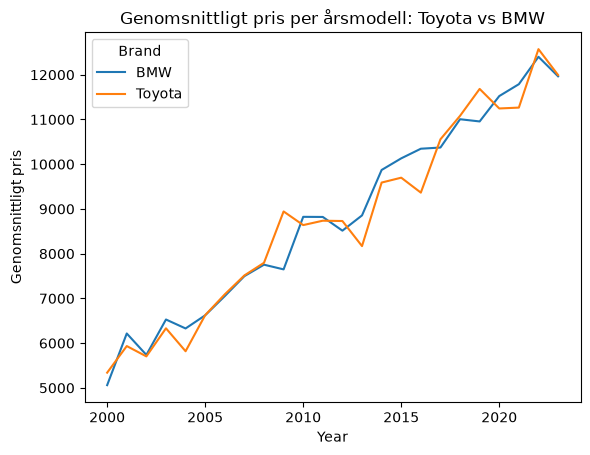

In [6]:
df.groupby(['Brand', 'Year'])['Price'].mean().unstack('Brand').plot()  # grupper data per märke och årsmodell
plt.xlabel('Year')
plt.ylabel('Genomsnittligt pris')
plt.title('Genomsnittligt pris per årsmodell: Toyota vs BMW')
plt.show()


## Förbereda datan för modellering

In [7]:
df_model = df.drop(columns=['Model'])  # behövr inga modeller i den här sammanhanget
df_model = pd.get_dummies(df_model, columns=['Brand', 'Fuel_Type', 'Transmission'], drop_first=True)  # Förvantlar till siffror brands

X = df_model.drop(columns=['Price'])  # features, oberoende variabler
y = df_model['Price'] # beroende varibel

X.head()


,Year,Engine_Size,Mileage,Doors,Owner_Count,Brand_Toyota,Fuel_Type_Electric,Fuel_Type_Hybrid,Fuel_Type_Petrol,Transmission_Manual,Transmission_Semi-Automatic
5,2007,2.7,157889,4,4,True,False,False,True,False,False
9,2005,3.1,107724,2,5,True,False,False,True,True,False
10,2013,1.3,296824,2,3,False,False,True,False,False,False
21,2000,4.6,41814,2,2,True,False,True,False,False,True
22,2003,2.0,136662,5,4,True,True,False,False,True,False


### Indelning av train data

In [8]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=40)  # 80% train_full, 20% test
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.3, random_state=36)  # av train_full: 70% train, 30% val

### Träna modeller

In [9]:
lr = LinearRegression()
lr.fit(X_train, y_train)

tree = DecisionTreeRegressor(random_state=42)
hyperparams = {"max_depth": [3, 5, 7, None]}  # sök efter bästa max_depth istället för att gissa

tree_gs = GridSearchCV(tree, hyperparams, scoring="neg_root_mean_squared_error", cv=5)
tree_gs.fit(X_train, y_train)

print(tree_gs.best_params_)

{'max_depth': 7}


### Utvärdera modeller på validation-data


In [10]:
lr_pred = lr.predict(X_val)  # låter modellen gissa priset i valideringsdatan
tree_pred = tree_gs.predict(X_val)

print("Linear Regression - MAE:", mean_absolute_error(y_val, lr_pred))  # genomsnittligt fel i kr/$
print("Linear Regression - RMSE:", root_mean_squared_error(y_val, lr_pred))  # straffar stora fel hårdare

print("Decision Tree - MAE:", mean_absolute_error(y_val, tree_pred))  # genomsnittligt fel i kr/$
print("Decision Tree - RMSE:", root_mean_squared_error(y_val, tree_pred))  # straffar stora fel hårdare

Linear Regression - MAE: 18.24220312399057
Linear Regression - RMSE: 105.55978171532172
Decision Tree - MAE: 992.8442370264029
Decision Tree - RMSE: 1246.8255548837187


### Slutgiltig utvärdering på test data


In [11]:
lr.fit(X_train_full, y_train_full)  # tränar om vinnande modellen på train+val innan test

final_pred = lr.predict(X_test)

print("Linear Regression (test) - MAE:", mean_absolute_error(y_test, final_pred))
print("Linear Regression (test) - RMSE:", root_mean_squared_error(y_test, final_pred))

Linear Regression (test) - MAE: 18.505386511259534
Linear Regression (test) - RMSE: 59.73432330486569


### Spara modellen

In [12]:
import joblib

lr.fit(X, y)  # tränar om på hela datasetet innan modellen sparas/produktionssätts

joblib.dump(lr, "bilpris_modell.pkl")
print("Modell sparad!")

Modell sparad!


#### Hela kedjan:

Notebook (koduppgift_bilpris.ipynb) — läser in car_price_dataset.csv, filtrerar till Toyota+BMW, gör om text-kolumner (Brand, Fuel_Type, Transmission) till True/False-kolumner (one-hot), delar upp i train/val/test, tränar två modeller (Linear Regression, Decision Tree med GridSearch för max_depth), jämför dem på valideringsdatan → Linear Regression vinner. Vi tränar sen om Linear Regression på train+val innan vi utvärderar den slutgiltigt på testdatan, och till sist tränar vi om den på hela datasetet innan den sparas (så modellen är tränad på så mycket data som möjligt innan den används skarpt).

Spara modellen — joblib.dump(lr, ...) → filen bilpris_modell.pkl. Det är den färdigtränade modellen "fryst" till en fil, så man slipper träna om den varje gång.

App (app.py) — separat Python-fil, körs med Streamlit (bash: .venv\Scripts\streamlit run app.py):

Laddar bilpris_modell.pkl med joblib.load (samma modell, ingen ny träning)
Visar inputfält (märke, år, mätarställning, drivmedel osv) som användaren fyller i
När man klickar "Beräkna pris": bygger en rad med exakt samma kolumner modellen förväntar sig (samma one-hot-format som i notebooken)
Skickar raden till model.predict(...) → visar predikterat pris
Kärnlogiken i en mening: notebooken tränar och sparar en "hjärna" (modellen), appen laddar in den hjärnan och frågar den om nya bilar den aldrig sett.